In [1]:
import pandas as pd

In [2]:
df = pd.read_json("KR_influencer_insta_comments.json")

In [3]:
df

,postUrl,commentUrl,id,text,ownerUsername,ownerProfilePicUrl,timestamp,repliesCount,replies,likesCount,owner,url,inputUrl,requestErrorMessages,error,errorDescription,media,parentCommentUrl
0,https://www.instagram.com/p/B8p_a99l3Fx/,https://www.instagram.com/p/B8p_a99l3Fx/c/1785...,1.785630e+16,지지.응원,gogitoergo11111,https://scontent.cdninstagram.com/v/t51.2885-1...,2023-01-19 05:50:26+00:00,0.0,[],0.0,"{'fbid_v2': '17841450568940282', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1809...,1.809368e+16,깔게 없으니 지연됬쥬??🙂,queen_barbibi,https://scontent-lax3-1.cdninstagram.com/v/t51...,2026-01-09 13:32:36+00:00,0.0,[],9.0,"{'fbid_v2': '17841400293861404', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1784...,1.784540e+16,👏,good_927,https://scontent-lax3-2.cdninstagram.com/v/t51...,2026-01-09 16:45:21+00:00,0.0,[],0.0,"{'fbid_v2': '17841411019370760', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1795...,1.795852e+16,투데이코리아 불나라🔥🔥🔥,roni__hair,https://scontent-lax7-1.cdninstagram.com/v/t51...,2026-01-10 11:44:51+00:00,0.0,[],0.0,"{'fbid_v2': '17841406986377275', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1808...,1.808728e+16,13일에는 무죄가 확실해지면 좋겠네요🥺🇰🇷,bliss.799,https://scontent-lax3-1.cdninstagram.com/v/t51...,2026-01-09 13:19:39+00:00,0.0,[],103.0,"{'fbid_v2': '17841457754112195', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123713,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1797...,1.797717e+16,한국은 ㅁ,giryongkimkim,https://scontent-ord5-3.cdninstagram.com/v/t51...,2026-01-13 08:31:02+00:00,0.0,[],0.0,"{'fbid_v2': '17841475613575857', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
123714,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1803...,1.803200e+16,이란집고 다음은 어디인고,kcr527619,https://scontent-ord5-1.cdninstagram.com/v/t51...,2026-01-13 08:24:18+00:00,0.0,[],0.0,"{'fbid_v2': '17841401580006849', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
123715,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1811...,1.811624e+16,코리아도 부탁해요~ 트럼프형🔥,best_chef_bkc,https://scontent-ord5-1.cdninstagram.com/v/t51...,2026-01-13 07:48:19+00:00,0.0,[],0.0,"{'fbid_v2': '17841406038837482', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
123716,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1810...,1.810287e+16,,ylji__1,https://scontent-ord5-1.cdninstagram.com/v/t51...,2026-01-13 06:49:55+00:00,0.0,[],0.0,"{'fbid_v2': '17841476272549539', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,"{'gif_media_id': '9ZvhlMUfkcNKKVrRs7', 'id': '...",NaN


In [3]:
import pandas as pd

# comments dataframe
comments_df = df.copy()

# rename commenter column so it's clear
comments_df = comments_df.rename(columns={"ownerUsername": "commenterUsername"})

# posts metadata dataframe
posts_df = pd.read_json("KR_influencer_insta_posts.json")

# keep only rows that are actual posts, not account URLs
posts_df = posts_df[posts_df["url"].str.contains("/p/", na=False)].copy()

# rename columns to reflect post owner
posts_df = posts_df.rename(columns={
    "url": "postUrl",
    "ownerUsername": "postOwnerUsername",
    "ownerFullName": "postOwnerFullName"
})

# keep only needed columns
post_owner_map = posts_df[["postUrl", "postOwnerUsername", "postOwnerFullName"]].drop_duplicates()

# merge into comments
merged_df = comments_df.merge(post_owner_map, on="postUrl", how="left")

In [5]:
merged_df

,postUrl,commentUrl,id,text,commenterUsername,ownerProfilePicUrl,timestamp,repliesCount,replies,likesCount,owner,url,inputUrl,requestErrorMessages,error,errorDescription,media,parentCommentUrl,postOwnerUsername,postOwnerFullName
0,https://www.instagram.com/p/B8p_a99l3Fx/,https://www.instagram.com/p/B8p_a99l3Fx/c/1785...,1.785630e+16,지지.응원,gogitoergo11111,https://scontent.cdninstagram.com/v/t51.2885-1...,2023-01-19 05:50:26+00:00,0.0,[],0.0,"{'fbid_v2': '17841450568940282', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,goodmorningcc,굿모닝충청
1,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1809...,1.809368e+16,깔게 없으니 지연됬쥬??🙂,queen_barbibi,https://scontent-lax3-1.cdninstagram.com/v/t51...,2026-01-09 13:32:36+00:00,0.0,[],9.0,"{'fbid_v2': '17841400293861404', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,chanhyeokgim,이대남의우회전
2,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1784...,1.784540e+16,👏,good_927,https://scontent-lax3-2.cdninstagram.com/v/t51...,2026-01-09 16:45:21+00:00,0.0,[],0.0,"{'fbid_v2': '17841411019370760', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,chanhyeokgim,이대남의우회전
3,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1795...,1.795852e+16,투데이코리아 불나라🔥🔥🔥,roni__hair,https://scontent-lax7-1.cdninstagram.com/v/t51...,2026-01-10 11:44:51+00:00,0.0,[],0.0,"{'fbid_v2': '17841406986377275', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,chanhyeokgim,이대남의우회전
4,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1808...,1.808728e+16,13일에는 무죄가 확실해지면 좋겠네요🥺🇰🇷,bliss.799,https://scontent-lax3-1.cdninstagram.com/v/t51...,2026-01-09 13:19:39+00:00,0.0,[],103.0,"{'fbid_v2': '17841457754112195', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,chanhyeokgim,이대남의우회전
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123713,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1797...,1.797717e+16,한국은 ㅁ,giryongkimkim,https://scontent-ord5-3.cdninstagram.com/v/t51...,2026-01-13 08:31:02+00:00,0.0,[],0.0,"{'fbid_v2': '17841475613575857', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,anchorjin,김진 앵커
123714,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1803...,1.803200e+16,이란집고 다음은 어디인고,kcr527619,https://scontent-ord5-1.cdninstagram.com/v/t51...,2026-01-13 08:24:18+00:00,0.0,[],0.0,"{'fbid_v2': '17841401580006849', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,anchorjin,김진 앵커
123715,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1811...,1.811624e+16,코리아도 부탁해요~ 트럼프형🔥,best_chef_bkc,https://scontent-ord5-1.cdninstagram.com/v/t51...,2026-01-13 07:48:19+00:00,0.0,[],0.0,"{'fbid_v2': '17841406038837482', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,anchorjin,김진 앵커
123716,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1810...,1.810287e+16,,ylji__1,https://scontent-ord5-1.cdninstagram.com/v/t51...,2026-01-13 06:49:55+00:00,0.0,[],0.0,"{'fbid_v2': '17841476272549539', 'full_name': ...",NaN,NaN,NaN,NaN,NaN,"{'gif_media_id': '9ZvhlMUfkcNKKVrRs7', 'id': '...",NaN,anchorjin,김진 앵커


In [4]:
pol_df = pd.read_excel(r"C:\Users\chldn\OneDrive\바탕 화면\Influencer_YouTube.xlsx")
pol_df

,Channel,YouTube Link,Instagram Link,Stance,channelName,postOwnerFullName
0,가로세로연구소,https://www.youtube.com/@HOVERLAB2018,https://www.instagram.com/hover_lab/,Right,가로세로연구소,가로세로연구소
1,감동란,https://www.youtube.com/@gamdonglan,https://www.instagram.com/gamdonglantv4.0/,Right,감동란TV 4.0 GamdonglanTV,NaN
2,강신업,https://www.youtube.com/@KangshinupTV,NaN,Right,강신업TV,NaN
3,강용석의 인싸it,https://www.youtube.com/@inssait,https://www.instagram.com/kang__yongseok/,Right,인싸it,강용석
4,고논,https://www.youtube.com/@%EA%B3%A0%EB%85%BC,https://www.instagram.com/ko_non21/,Right,고논,고논
...,...,...,...,...,...,...
205,김영윤TV_폴리티코 연구소,https://www.youtube.com/channel/UCkW4UscEu3d4E...,https://www.instagram.com/kimyoungyun2022,Right,NaN,NaN
206,뉴스토마토,https://www.youtube.com/@newstomatoTV,https://www.instagram.com/kwangjae.today,Left,NaN,NaN
207,박성태의 뉴스쇼,https://www.youtube.com/@%EB%B0%95%EC%84%B1%ED...,NaN,Left,NaN,NaN
208,멸콩TV,https://www.youtube.com/@%EB%A9%B8%EC%BD%A9TV,NaN,Right,NaN,NaN


In [5]:
merged = merged_df.merge(
    pol_df[["postOwnerFullName", "Stance"]],
    on="postOwnerFullName",
    how="left"
)

In [8]:
merged

,postUrl,commentUrl,id,text,commenterUsername,ownerProfilePicUrl,timestamp,repliesCount,replies,likesCount,...,url,inputUrl,requestErrorMessages,error,errorDescription,media,parentCommentUrl,postOwnerUsername,postOwnerFullName,Stance
0,https://www.instagram.com/p/B8p_a99l3Fx/,https://www.instagram.com/p/B8p_a99l3Fx/c/1785...,1.785630e+16,지지.응원,gogitoergo11111,https://scontent.cdninstagram.com/v/t51.2885-1...,2023-01-19 05:50:26+00:00,0.0,[],0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,goodmorningcc,굿모닝충청,Left
1,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1809...,1.809368e+16,깔게 없으니 지연됬쥬??🙂,queen_barbibi,https://scontent-lax3-1.cdninstagram.com/v/t51...,2026-01-09 13:32:36+00:00,0.0,[],9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,chanhyeokgim,이대남의우회전,Right
2,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1784...,1.784540e+16,👏,good_927,https://scontent-lax3-2.cdninstagram.com/v/t51...,2026-01-09 16:45:21+00:00,0.0,[],0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,chanhyeokgim,이대남의우회전,Right
3,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1795...,1.795852e+16,투데이코리아 불나라🔥🔥🔥,roni__hair,https://scontent-lax7-1.cdninstagram.com/v/t51...,2026-01-10 11:44:51+00:00,0.0,[],0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,chanhyeokgim,이대남의우회전,Right
4,https://www.instagram.com/p/DTSoS9TEfu-/,https://www.instagram.com/p/DTSoS9TEfu-/c/1808...,1.808728e+16,13일에는 무죄가 확실해지면 좋겠네요🥺🇰🇷,bliss.799,https://scontent-lax3-1.cdninstagram.com/v/t51...,2026-01-09 13:19:39+00:00,0.0,[],103.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,chanhyeokgim,이대남의우회전,Right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353063,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1797...,1.797717e+16,한국은 ㅁ,giryongkimkim,https://scontent-ord5-3.cdninstagram.com/v/t51...,2026-01-13 08:31:02+00:00,0.0,[],0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,anchorjin,김진 앵커,Right
353064,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1803...,1.803200e+16,이란집고 다음은 어디인고,kcr527619,https://scontent-ord5-1.cdninstagram.com/v/t51...,2026-01-13 08:24:18+00:00,0.0,[],0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,anchorjin,김진 앵커,Right
353065,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1811...,1.811624e+16,코리아도 부탁해요~ 트럼프형🔥,best_chef_bkc,https://scontent-ord5-1.cdninstagram.com/v/t51...,2026-01-13 07:48:19+00:00,0.0,[],0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,anchorjin,김진 앵커,Right
353066,https://www.instagram.com/p/DTZUTrpk-oN/,https://www.instagram.com/p/DTZUTrpk-oN/c/1810...,1.810287e+16,,ylji__1,https://scontent-ord5-1.cdninstagram.com/v/t51...,2026-01-13 06:49:55+00:00,0.0,[],0.0,...,NaN,NaN,NaN,NaN,NaN,"{'gif_media_id': '9ZvhlMUfkcNKKVrRs7', 'id': '...",NaN,anchorjin,김진 앵커,Right


In [9]:
merged[["commenterUsername", "postOwnerFullName", "Stance"]]

,commenterUsername,postOwnerFullName,Stance
0,gogitoergo11111,굿모닝충청,Left
1,queen_barbibi,이대남의우회전,Right
2,good_927,이대남의우회전,Right
3,roni__hair,이대남의우회전,Right
4,bliss.799,이대남의우회전,Right
...,...,...,...
353063,giryongkimkim,김진 앵커,Right
353064,kcr527619,김진 앵커,Right
353065,best_chef_bkc,김진 앵커,Right
353066,ylji__1,김진 앵커,Right


In [6]:
counts = (
    merged.groupby(["commenterUsername"])["id"]
    .count()
    .reset_index(name="n_comments")
)

active_users = counts.loc[counts["n_comments"] >= 20, "commenterUsername"].unique()

filtered_df = merged[merged["commenterUsername"].isin(active_users)]

In [7]:
import pandas as pd
pd.set_option('display.max_colwidth', None)


In [8]:
filtered_df

,postUrl,commentUrl,id,text,commenterUsername,ownerProfilePicUrl,timestamp,repliesCount,replies,likesCount,...,url,inputUrl,requestErrorMessages,error,errorDescription,media,parentCommentUrl,postOwnerUsername,postOwnerFullName,Stance
16,https://www.instagram.com/p/DW1JV2lDDku/,https://www.instagram.com/p/DW1JV2lDDku/c/18336525184175942,1.833653e+16,대한민국 이재명 대통령 품격이 들어납니다 국힘당 도와주세요,bongsuk520,https://scontent-dfw6-1.cdninstagram.com/v/t51.89012-19/573323465_1219825463302212_7278921664109726296_n.png?stp=dst-webp_s150x150&_nc_cat=1&ig_cache_key=YW5vbnltb3VzX3Byb2ZpbGVfcGlj.3-ccb7-5&ccb=7-5&_nc_sid=669407&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLnd3dy5DMyJ9&_nc_ohc=pq70L7RI3VkQ7kNvwE7HpYD&_nc_oc=AdoFxvMgkje0uU26wzq32Lh20Um3F3RO6tnrDGFu2y5vRd3iamhvXFdUdQ9K9VUrAeo&_nc_ad=z-m&_nc_cid=0&_nc_zt=24&_nc_ht=scontent-dfw6-1.cdninstagram.com&_nc_gid=pAoSCKLxeKguHiJNOubspw&_nc_ss=7a3ba&oh=00_Af3LjGgA8y6I09DkB1IiHw70pNugE2Xov-5fqnmCKnp7oA&oe=69DCBC59,2026-04-07 13:12:57+00:00,0.0,[],3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rightsound1974,[공식]바른소리,Left
19,https://www.instagram.com/p/DW1JV2lDDku/,https://www.instagram.com/p/DW1JV2lDDku/c/18521496268075952,1.852150e+16,ㅋㅋㅋ,pkpk648,https://scontent-dfw6-1.cdninstagram.com/v/t51.2885-19/440889184_3454129688222507_5854183199841779876_n.jpg?stp=dst-jpg_e0_s150x150_tt6&_nc_cat=101&ig_cache_key=GGBvRxorGxM9g0UMAKQAoXyaPD5RbkULAAAB1501500j-ccb7-5&ccb=7-5&_nc_sid=669407&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLnd3dy4xMDgwLkMzIn0%3D&_nc_ohc=S6P9yduE7cUQ7kNvwGO0DUM&_nc_oc=AdpqfTcB-A-KZthQSDS2Yzzcam945y2xH_-BTgMNAJ0kvqZaufNuo3jN-shzETAAFt8&_nc_ad=z-m&_nc_cid=0&_nc_zt=24&_nc_ht=scontent-dfw6-1.cdninstagram.com&_nc_ss=7a3ba&oh=00_Af2TFGn9x4xc9Qjo4sWx6-DiqsK6Rod_7TBh7HOWzsGLew&oe=69DCD14F,2026-04-08 07:45:09+00:00,0.0,[],0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rightsound1974,[공식]바른소리,Left
20,https://www.instagram.com/p/DW1JV2lDDku/,https://www.instagram.com/p/DW1JV2lDDku/c/18006788840892918,1.800679e+16,대한민국 국민 모두가 원하는 것은\n대한민국 선거문화가 \n정말 떳떳하고. 정정당당하게.\n사전선거 없애고. 선거 관리관 직인 찍고.\n당일 투표하고. 수개표 해서\n선거혁명 해야 한다.\n대한민국이 세계를 향해\n투명하고 깨끗한 선진화된 1등\n선거문화 진정한 민주주의를 보여주자.\n이게 진정한 대한민국의 국력이다.\n세계 1등 선거혁명!\n대한민국ㅡ홧팅,hwan_2255,https://scontent-dfw5-1.cdninstagram.com/v/t51.2885-19/99064097_248898052837341_6717044695907696640_n.jpg?stp=dst-jpg_e0_s150x150_tt6&_nc_cat=105&ig_cache_key=GCGZ5wXdTwYYX_IAAAAAAACQvDddbkULAAAB1501500j-ccb7-5&ccb=7-5&_nc_sid=669407&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLnd3dy4xMDgwLkMzIn0%3D&_nc_ohc=Wc2HrRMvQ_YQ7kNvwE2389x&_nc_oc=AdriL84oBHGoupbTGFudozE78S-erCP69YKKokE3QmxIQTKN5C4Pb49Lsf_J4W0YBIw&_nc_ad=z-m&_nc_cid=0&_nc_zt=24&_nc_ht=scontent-dfw5-1.cdninstagram.com&_nc_ss=7a3ba&oh=00_Af2MOGLNW7Tt0fmMeEwoZ6vQoXd-OSKUbSxMzum53eNh4w&oe=69DCE49B,2026-04-07 16:12:05+00:00,0.0,[],1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rightsound1974,[공식]바른소리,Left
22,https://www.instagram.com/p/DU-2_4ID5Nf/,https://www.instagram.com/p/DU-2_4ID5Nf/c/18038323586536294,1.803832e+16,👏👏👏👏👏👏👏👏👏👏👏👏👏👏,imisug0616,https://scontent-ams2-1.cdninstagram.com/v/t51.2885-19/289265618_715573762875701_8724190835931834837_n.jpg?stp=dst-jpg_e0_s150x150_tt6&_nc_cat=111&ig_cache_key=GNLXPRE1YfJ-z4oCANVpb7BXjRJ5bkULAAAB1501500j-ccb7-5&ccb=7-5&_nc_sid=669407&efg=eyJ2ZW5jb2RlX3RhZyI6InByb2ZpbGVfcGljLnd3dy4xMDgwLkMzIn0%3D&_nc_ohc=ZNwlXkzmR0IQ7kNvwFuSGws&_nc_oc=Adrtr6HYsTa9H_XFWF7ylrA90cvA3cnWMyNQZ2Op11v48R8ZY1l4EemR0sFa2SBSrZA&_nc_ad=z-m&_nc_cid=0&_nc_zt=24&_nc_ht=scontent-ams2-1.cdninstagram.com&_nc_ss=7a3ba&oh=00_Af1tMyKgNQVQwMtoSUpQ6pzlCnHSz-fyiN5w7hzD4MfRaw&oe=69DCE18E,2026-02-20 14:27:22+00:00,0.0,[],0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,agalchoi,최현준TV,Left
175,https://www.instagram.com/p/DWuL3iTEvT4/,https://www.instagram.com/p/DWuL3iTEvT4/c/17980822736825391,1.798082e+16,"공정경선 선거절차 무시하는 정청래를 제명하라\n\n---\n\n민주당 중앙당이 최근 각 지역 경선 후보들에게 황당한 공문을 내려보냈습니다.\n""이재명 대통령이 취임 전 촬영된 사진·영상을 선거홍보물에 활용하지 말라""\n이유는 '대통령의 당무 개입 의혹', '정치적 중립 위반 논란'이라고 합니다.\n\n저는 이 지침에 강하게 반대합니다. 논리적으로도, 정치적으로도 완전히 잘못된 결정입니다.\n첫째, 논리 자체가 성립하지 않습니다.\n취임 이전에 찍은 사진이 

In [12]:
user_counts = (
    filtered_df
    .groupby(['commenterUsername', 'Stance'])
    .size()
    .unstack(fill_value=0)
)

for col in ["Left", "Right"]:
    if col not in user_counts.columns:
        user_counts[col] = 0

user_counts["user_bias"] = (
    (user_counts["Right"] - user_counts["Left"]) /
    (user_counts["Right"] + user_counts["Left"])
)

In [13]:
user_counts = user_counts.reset_index()

user_counts["platform"] = "Instagram"
user_counts["producer_type"] = "Youtubers"

In [14]:
user_counts.to_csv("D:/School/2026 Spring/independent_study/datasets/youtubers/instagram/user_counts.csv", index=False)

In [15]:
user_counts

Stance,commenterUsername,Left,Right,user_bias,platform,producer_type
0,03020115ts,33,2,-0.885714,Instagram,Youtubers
1,0__0___0__000,38,0,-1.000000,Instagram,Youtubers
2,1007jeongmin,0,100,1.000000,Instagram,Youtubers
3,1361.ba,0,21,1.000000,Instagram,Youtubers
4,1_u._.h,39,1,-0.950000,Instagram,Youtubers
...,...,...,...,...,...,...
573,zedi000,25,0,-1.000000,Instagram,Youtubers
574,zibry098,22,0,-1.000000,Instagram,Youtubers
575,zirarizo,35,0,-1.000000,Instagram,Youtubers
576,zuua_o,0,20,1.000000,Instagram,Youtubers


In [16]:
len(user_counts)

578

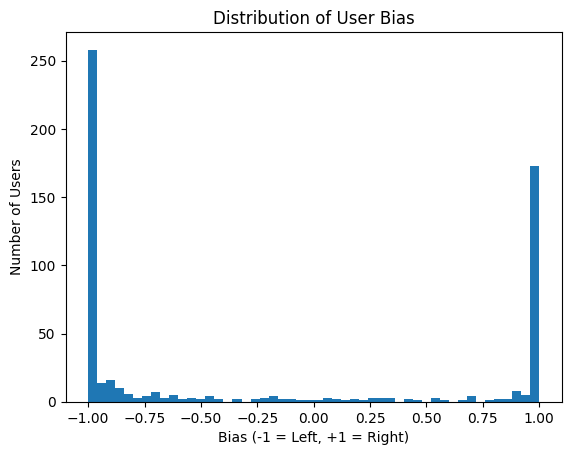

In [17]:
import matplotlib.pyplot as plt

plt.hist(user_counts["user_bias"], bins=50)
plt.title("Distribution of User Bias")
plt.xlabel("Bias (-1 = Left, +1 = Right)")
plt.ylabel("Number of Users")
plt.show()

In [18]:
import numpy as np
# total interactions (only left + right)
user_counts = user_counts.copy()
user_counts["total"] = user_counts["Left"] + user_counts["Right"]

# avoid division by zero
user_counts = user_counts[user_counts["total"] > 0]

# determine user side
user_counts["leaning"] = user_counts["user_bias"].apply(
    lambda x: "right" if x > 0.1 else ("left" if x < -0.1 else "center")
)

# compute cross-cutting exposure
def compute_cross_cutting(row):
    if row["leaning"] == "right":
        return row["Left"] / row["total"]
    elif row["leaning"] == "left":
        return row["Right"] / row["total"]
    else:
        return np.nan  # or 0, depending on your design

user_counts["cross_cutting"] = user_counts.apply(compute_cross_cutting, axis=1)

In [19]:
user_counts

Stance,commenterUsername,Left,Right,user_bias,platform,producer_type,total,leaning,cross_cutting
0,03020115ts,33,2,-0.885714,Instagram,Youtubers,35,left,0.057143
1,0__0___0__000,38,0,-1.000000,Instagram,Youtubers,38,left,0.000000
2,1007jeongmin,0,100,1.000000,Instagram,Youtubers,100,right,0.000000
3,1361.ba,0,21,1.000000,Instagram,Youtubers,21,right,0.000000
4,1_u._.h,39,1,-0.950000,Instagram,Youtubers,40,left,0.025000
...,...,...,...,...,...,...,...,...,...
573,zedi000,25,0,-1.000000,Instagram,Youtubers,25,left,0.000000
574,zibry098,22,0,-1.000000,Instagram,Youtubers,22,left,0.000000
575,zirarizo,35,0,-1.000000,Instagram,Youtubers,35,left,0.000000
576,zuua_o,0,20,1.000000,Instagram,Youtubers,20,right,0.000000


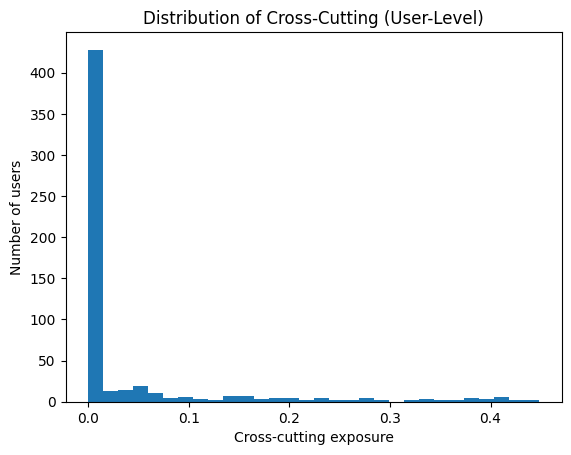

In [20]:
import matplotlib.pyplot as plt

plt.hist(user_counts["cross_cutting"].dropna(), bins=30)

plt.xlabel("Cross-cutting exposure")
plt.ylabel("Number of users")
plt.title("Distribution of Cross-Cutting (User-Level)")

plt.show()

In [21]:
bins = [20, 50, 100, 300, 1000, np.inf]
labels = ["20–49", "50–99", "100–299", "300–999", "1000+"]

user_counts["activity_band"] = pd.cut(
    user_counts["total"],
    bins=bins,
    labels=labels,
    right=False
)

In [22]:
band_summary = (
    user_counts
    .groupby("activity_band")[["user_bias", "cross_cutting"]]
    .mean()
    .reset_index()
)

C:\Users\chldn\AppData\Local\Temp\ipykernel_30648\2619608654.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("activity_band")[["user_bias", "cross_cutting"]]


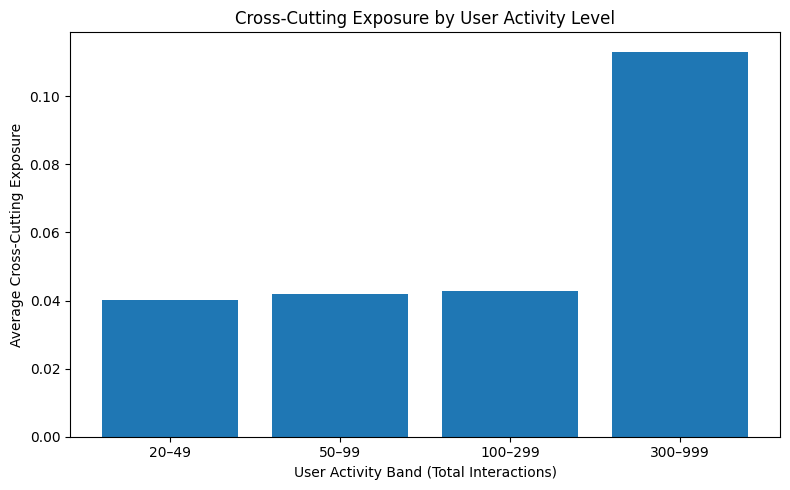

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(band_summary["activity_band"].astype(str),
        band_summary["cross_cutting"])

plt.xlabel("User Activity Band (Total Interactions)")
plt.ylabel("Average Cross-Cutting Exposure")
plt.title("Cross-Cutting Exposure by User Activity Level")

plt.tight_layout()
plt.show()

In [24]:
band_summary = (
    user_counts
    .dropna(subset=["cross_cutting"])
    .groupby("activity_band", observed=True)
    .apply(
        lambda g: np.average(
            g["cross_cutting"],
            weights=g["total"]
        )
    )
    .reset_index(name="weighted_cross_cutting")
)

C:\Users\chldn\AppData\Local\Temp\ipykernel_30648\3072711999.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


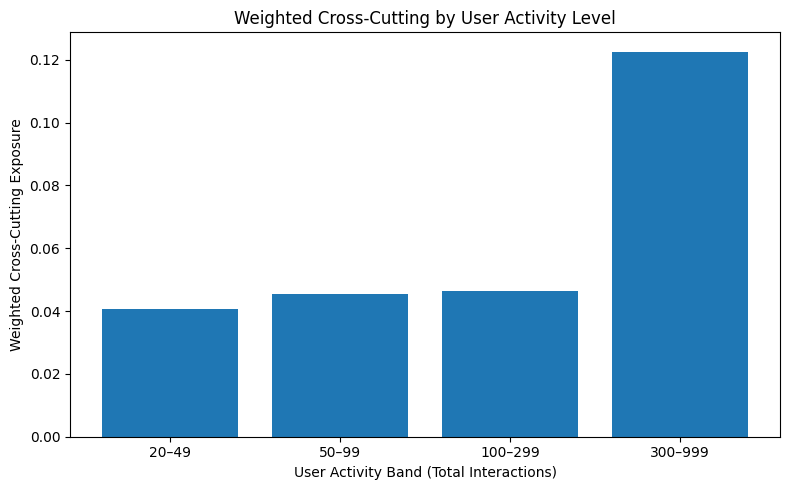

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    band_summary["activity_band"].astype(str),
    band_summary["weighted_cross_cutting"]
)

plt.xlabel("User Activity Band (Total Interactions)")
plt.ylabel("Weighted Cross-Cutting Exposure")
plt.title("Weighted Cross-Cutting by User Activity Level")

plt.tight_layout()
plt.show()

In [26]:
import numpy as np

band_stats = (
    user_counts
    .groupby("activity_band")["cross_cutting"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# Standard Error
band_stats["se"] = (
    band_stats["std"] /
    np.sqrt(band_stats["count"])
)

# 95% Confidence Interval
band_stats["ci95"] = 1.96 * band_stats["se"]

print(band_stats)

  activity_band      mean       std  count        se      ci95
0         20–49  0.040119  0.097611    409  0.004827  0.009460
1         50–99  0.041799  0.092126     65  0.011427  0.022397
2       100–299  0.042693  0.109340     24  0.022319  0.043745
3       300–999  0.113103  0.103123      3  0.059538  0.116694
4         1000+       NaN       NaN      0       NaN       NaN


C:\Users\chldn\AppData\Local\Temp\ipykernel_30648\2513221513.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("activity_band")["cross_cutting"]


In [27]:
# unweighted
band_unweighted = (
    user_counts
    .dropna(subset=["cross_cutting"])
    .groupby("activity_band")["cross_cutting"]
    .mean()
    .reset_index(name="unweighted")
)

# merge
band_compare = band_unweighted.merge(
    band_summary,
    on="activity_band"
)

C:\Users\chldn\AppData\Local\Temp\ipykernel_30648\1167140726.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("activity_band")["cross_cutting"]


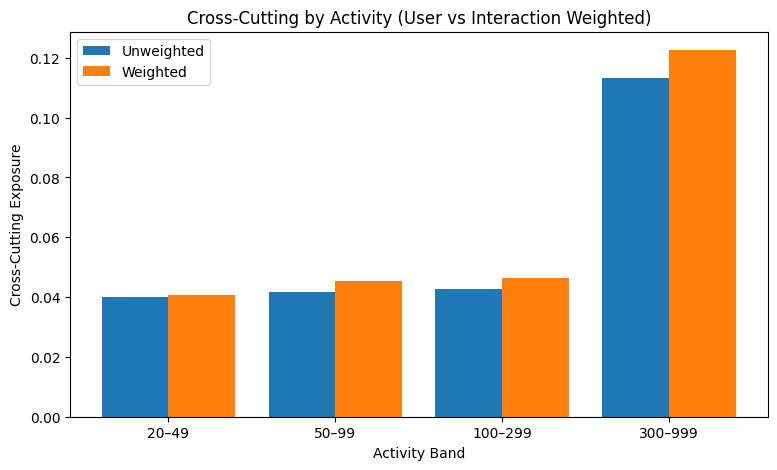

In [28]:
x = range(len(band_compare))

plt.figure(figsize=(9,5))

plt.bar(x, band_compare["unweighted"], width=0.4, label="Unweighted")
plt.bar([i+0.4 for i in x], band_compare["weighted_cross_cutting"], width=0.4, label="Weighted")

plt.xticks([i+0.2 for i in x], band_compare["activity_band"].astype(str))
plt.xlabel("Activity Band")
plt.ylabel("Cross-Cutting Exposure")
plt.title("Cross-Cutting by Activity (User vs Interaction Weighted)")

plt.legend()
plt.show()